<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjhamilton/weeks/week_01/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [3]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [4]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df.head()
#df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_428/3348629523.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_428/3348629523.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,hour,minute,second,latitude,longitude,correctedArea,CAUnc,uniqueID,CYCLE,survey
0,1825-11-05,12.0,30.0,0.0,-1.2,331.8,2120.0,570.0,101.0,NaN,1.0
3,1825-11-08,12.0,0.0,0.0,-17.9,321.8,670.0,190.0,102.0,NaN,1.0
4,1825-11-09,14.0,45.0,0.0,-14.6,320.7,500.0,150.0,102.0,NaN,1.0
5,1825-11-10,12.0,0.0,0.0,-27.4,318.1,520.0,150.0,103.0,NaN,1.0
6,1825-11-11,12.0,0.0,0.0,-26.3,320.8,470.0,140.0,103.0,NaN,1.0


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


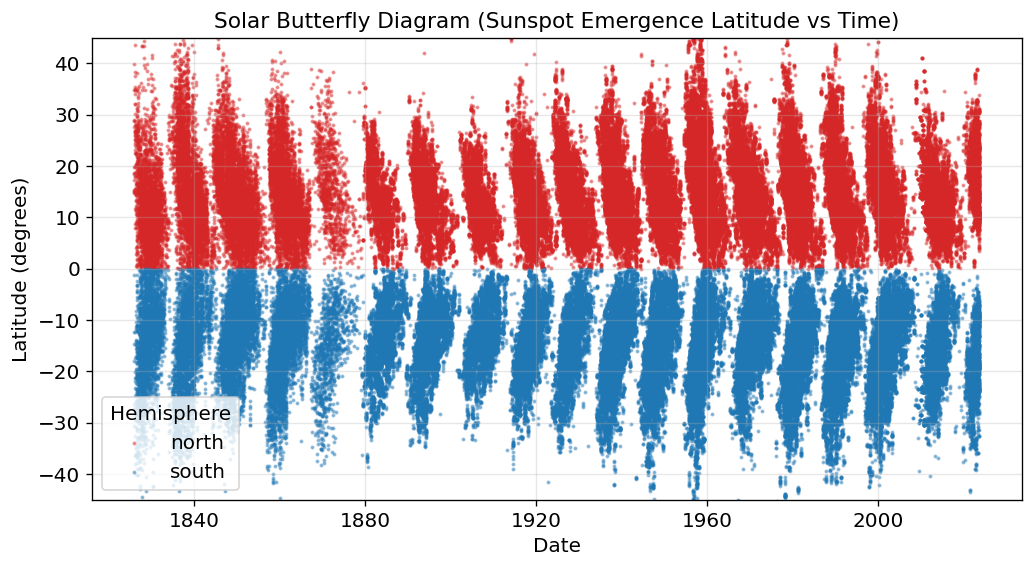

In [5]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


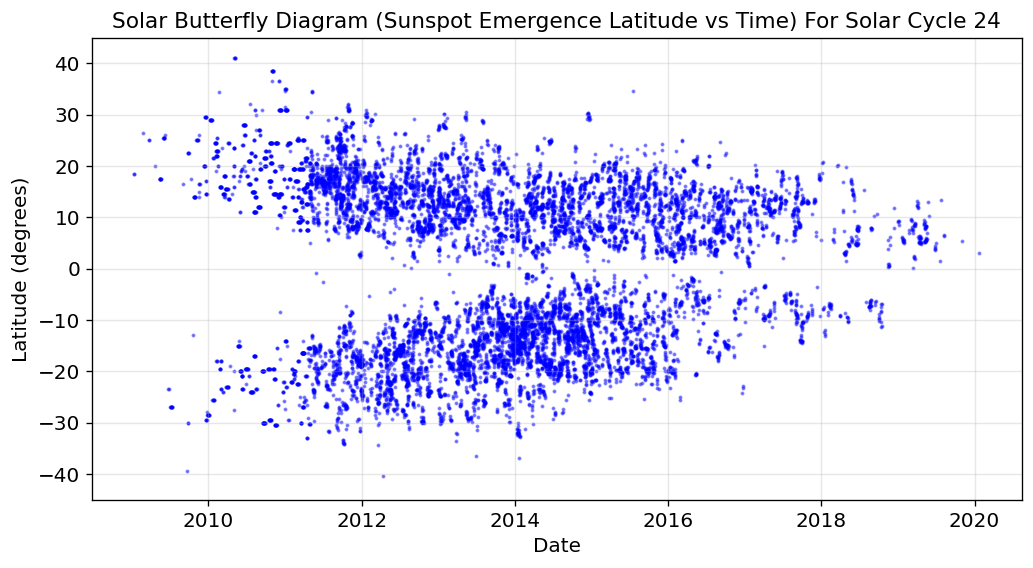

In [6]:
import matplotlib.pyplot as plt

# Filter the DataFrame for solar cycle 24
df_cycle_24 = df[df["CYCLE"] == 24].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_cycle_24["date"], df_cycle_24["latitude"], s=2, c='Blue', alpha=0.4)
ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time) For Solar Cycle 24")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
plt.show()

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_428/1086587285.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  mean_lat_north = df[df["hemisphere"] == "north"].set_index("date")["latitude"].resample('Y').mean()
/tmp/ipykernel_428/1086587285.py:6: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  mean_lat_south = df[df["hemisphere"] == "south"].set_index("date")["latitude"].resample('Y').mean()


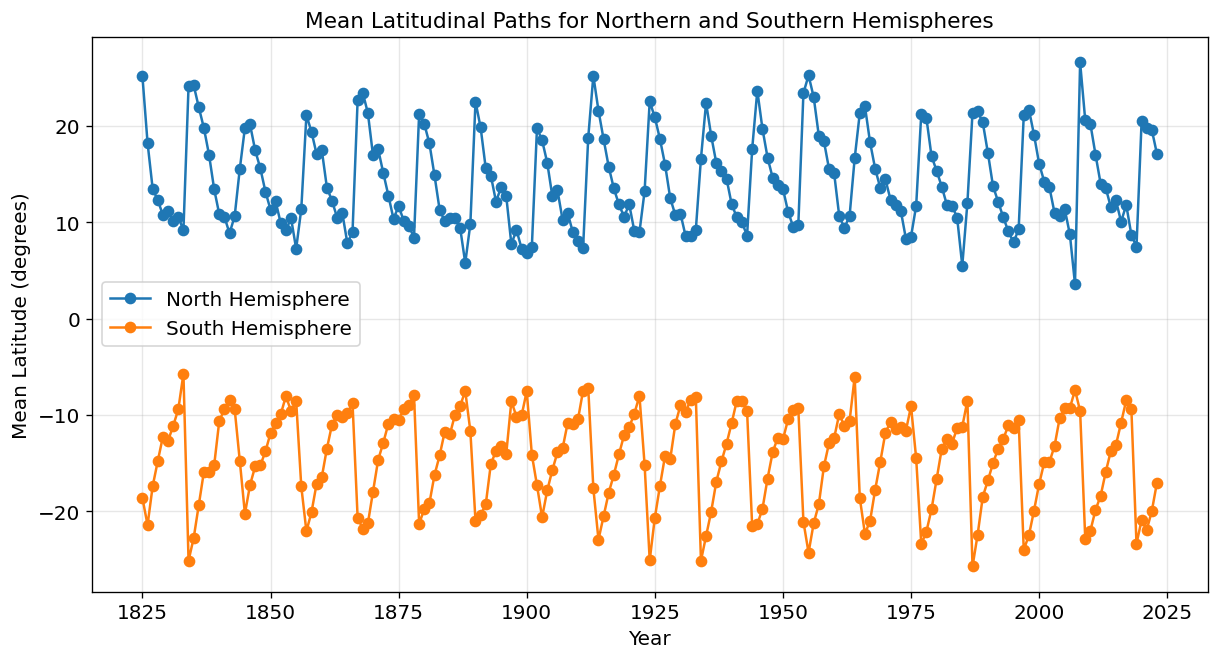

In [8]:
# Your code here: Calculate and plot mean latitudinal paths

# Group the data by hemisphere and calculate the mean latitude for each year
# Using resample('YE') on the 'date' column after setting it as index allows for time-based aggregation.
mean_lat_north = df[df["hemisphere"] == "north"].set_index("date")["latitude"].resample('YE').mean()
mean_lat_south = df[df["hemisphere"] == "south"].set_index("date")["latitude"].resample('YE').mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(mean_lat_north.index.year, mean_lat_north.values, label="North Hemisphere", marker='o', linestyle='-')
ax.plot(mean_lat_south.index.year, mean_lat_south.values, label="South Hemisphere", marker='o', linestyle='-')

ax.set_title("Mean Latitudinal Paths for Northern and Southern Hemispheres")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Latitude (degrees)")
ax.legend()
ax.grid(True)
plt.show()

The average evolution of the latitude placement of the sunspots varies over the sunspot cycle. The spots start at high latitudes (positive and negative) and evolve towards the equator in a relative linear fashion. It could be noted that for weaker cycles (smaller latitude variances), there seems to be kinks in the average latitudinal evolution. It is not as linear at the stronger cycles.

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*
Here is the response:
Be Specific with Your Goal: Clearly state what you want to learn or achieve. Instead of just "Explain machine learning," try "Explain the concept of neural networks and how they learn to classify images" or "Summarize the lifecycle of a solar flare and its impact on Earth."

Define Your Current Knowledge Level: Tell the AI what you already know (or don't know). This helps it tailor the explanation.

"I'm new to Python, can you explain this machine learning concept using simple analogies?"
"I have a basic understanding of electromagnetism; explain how solar magnetic fields lead to sunspots."
Specify the Desired Format and Depth: Do you want a brief summary, a detailed explanation, code examples, analogies, or a step-by-step guide?

"Give me a high-level overview of supervised vs. unsupervised learning, with an example for each."
"Provide a Python code example demonstrating a simple linear regression model from scratch."
"Explain the Carrington Event in solar physics, detailing its causes, effects, and historical significance, using a narrative style."
Ask for Analogies or Metaphors: These are incredibly helpful for grasping complex ideas.

"Explain gradient descent using an analogy that a non-technical person can understand."
"Can you use a fluid dynamics analogy to describe solar plasma behavior?"
Request Code Examples (for ML): If learning machine learning, ask for practical code snippets.

"Show me how to implement a decision tree classifier in scikit-learn."
"Provide a TensorFlow example for building a convolutional neural network for image recognition."
Ask 'Why' and 'How': Don't just settle for 'what.' Understanding the underlying reasons and mechanisms deepens your learning.

"Why is regularization important in machine learning models?"
"How do solar observatories measure the magnetic field of the sun?"
Break Down Complex Topics: If a topic is vast, ask the AI to break it into smaller, manageable chunks.

"Outline the key components of a machine learning project workflow, from data collection to deployment."
"What are the main layers of the sun's atmosphere, and what are their primary characteristics?"
Test Your Understanding: After an explanation, ask the AI to quiz you or provide scenarios.

"Give me a problem where I would use k-means clustering, and explain why."
"Describe a hypothetical scenario involving a major solar storm, and ask me what its potential impacts would be."
Iterate and Refine: If the first answer isn't quite right, follow up. "Can you elaborate on point X?" or "Could you simplify that explanation further?"

Connect Concepts: Ask the AI to draw connections between different areas of your learning.

"How might machine learning techniques be applied to analyze sunspot data for predicting solar activity?"

Reflection: This was very enlightening. They suggest to be more precise/concise in our questions. To help, it is a good idea to provide an idea of where our knowledge lies in the topic. I believe with each notebook, I will use the assistant to dive deeper into concepts that I am unfamiliar with and to build my knowledge of coding as I am not a strong coder. It will help me build understanding of my mistakes and how to approach my codes. I will always try to complete the coding task first then will seek the aid of the assistant if stuck or have errors.

Here is a copy of the conversation with the AI assistant:

How can I isolate solar cycle 24?
You can isolate solar cycle 24 by filtering the df DataFrame using the CYCLE column. I've updated the code in cell 9a656a73 to do this and also corrected a typo in the plotting function.


Can you help with this error in cell 7
The error in cell 7 (code cell 8b03228d) is due to comparing string values ('north', 'south') in the 'hemisphere' column with an integer. I've corrected this by filtering directly on the string values and using resample('Y') on the 'date' column to calculate the mean latitude per year for each hemisphere, which is a more idiomatic way to handle time-series aggregation in pandas.

You're seeing a FutureWarning in cell 8b03228d because the resample('Y') function is deprecated. I'll update it to resample('YE') to prevent future issues.

After fixing that, the plot shows the mean latitudinal paths for the Northern and Southern Hemispheres over time. Each line represents the average latitude of sunspot emergence in that hemisphere per year. We can observe a clear cyclical pattern, where sunspots initially appear at higher latitudes at the beginning of a solar cycle and then migrate towards the equator as the cycle progresses. This is a fundamental characteristic of the solar butterfly diagram.


I am new to pandas. Can you explain the set up of the dataframes and how to call certain values or aggregate?
Certainly! Let's break down how the dataframes are set up and how you can work with them in pandas.

1. DataFrame Setup (df)

When we load the composite_sunspot_groups_daily_measurements_10_23.csv file, it creates a pandas DataFrame named df. Think of a DataFrame as a table or a spreadsheet. Each column has a name (like date, latitude, CYCLE, hemisphere), and each row represents a single observation (in this case, a daily sunspot group measurement).

df.head(): This shows you the first 5 rows of the DataFrame, giving you a quick peek at the data and its columns.
df.info(): (You can run this in a new cell) This would give you a summary of the DataFrame, including the column names, the number of non-null values, and their data types (e.g., datetime64[ns] for dates, float64 for numbers, object for strings).
2. Calling Certain Values (Selection)

Selecting a single column: You can access a column by its name using square brackets, like df['latitude']. This will return a pandas Series (a single column of data).
Selecting multiple columns: You can pass a list of column names: df[['date', 'latitude', 'CYCLE']].
Filtering rows based on a condition: This is very powerful. For example:
df[df['latitude'] > 0] would give you all rows where the latitude is greater than 0.
df[df['hemisphere'] == 'north'] selects all rows where the hemisphere is 'north'.
df[df['CYCLE'] == 24] is what we used to isolate data for solar cycle 24.
You can combine conditions using & (AND) or | (OR), like df[(df['CYCLE'] == 24) & (df['latitude'] > 0)].
3. Aggregating Data

Aggregation means summarizing data. You've seen two main ways in this notebook:

groupby(): This function is used to group rows based on one or more columns and then apply an aggregation function (like mean(), sum(), count(), min(), max()) to each group.

In the Mean Latitudinal Paths exercise, we implicitly grouped by hemisphere when we did df[df["hemisphere"] == "north"] and df[df["hemisphere"] == "south"] and then further aggregated by year using resample().
resample(): This is specifically designed for time-series data when your DataFrame has a DatetimeIndex (which set_index("date") creates). It allows you to group data by different time frequencies (e.g., daily, monthly, yearly).

resample('YE').mean(): This groups the data by 'Year End' and then calculates the mean of the specified column for each year. This is how we got the mean_lat_north and mean_lat_south for each year.
In summary:

df: Your main table of sunspot data.
df[...]: Used for selecting specific columns or filtering rows based on conditions.
.groupby(...): Used to perform operations on groups of rows.
.resample(...): Used for time-based grouping and aggregation when you have date/time data.
These are fundamental concepts in pandas, and practicing with them will make you very proficient in data manipulation!


Thank you so much!
You're very welcome! I'm glad I could help clarify things for you. Let me know if you have any more questions as you continue exploring the notebook.